# ___Phylogenetic regression___
-------------------------

In [3]:
print(R.version$version.string)

[1] "R version 4.5.2 (2025-10-31 ucrt)"


In [2]:
library("ape")
library("phytools")
library("nlme")

Loading required package: maps



In [13]:
primate_eyes <- read.csv("./primateEyes.csv", stringsAsFactors = TRUE)
primate_tree <- ape::read.tree("./primateEyes.phy") # phylogenetic tree file for the primate species in the .csv file

In [14]:
head(primate_eyes)

,Genus_species,Group,Skull_length,Optic_foramen_area,Orbit_area,Activity_pattern,Activity_pattern_code
,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<fct>,<int>
1,Allenopithecus_nigroviridis,Anthropoid,98.5,7.0,298.7,Diurnal,0
2,Alouatta_palliata,Anthropoid,109.8,5.3,382.3,Diurnal,0
3,Alouatta_seniculus,Anthropoid,108.0,8.0,359.4,Diurnal,0
4,Aotus_trivirgatus,Anthropoid,60.5,3.1,297.4,Nocturnal,2
5,Arctocebus_aureus,Prosimian,49.5,1.2,134.8,Nocturnal,2
6,Arctocebus_calabarensis,Prosimian,53.8,1.6,156.6,Nocturnal,2


In [12]:
str(primate_tree$tip.label) # 90 species

 chr [1:90] "Allenopithecus_nigroviridis" "Cercopithecus_mitis" ...


In [15]:
corr <- ape::corBrownian(phy = primate_tree, form~Genus_species) # correlation matrix
ancova <- nlme::gls(log(Orbit_area)~log(Skull_length)+Activity_pattern, data = primate_eyes, correlation = corr) # fitting a GLS model
anova(ancova)

Warning message in Initialize.corPhyl(X[[i]], ...):
"No covariate specified, species will be taken as ordered in the data frame. To avoid this message, specify a covariate containing the species names with the 'form' argument."


,numDF,F-value,p-value
,<int>,<dbl>,<dbl>
(Intercept),1,608.32477,9.071644e-41
log(Skull_length),1,558.19332,2.288353e-39
Activity_pattern,2,30.41525,1.024079e-10


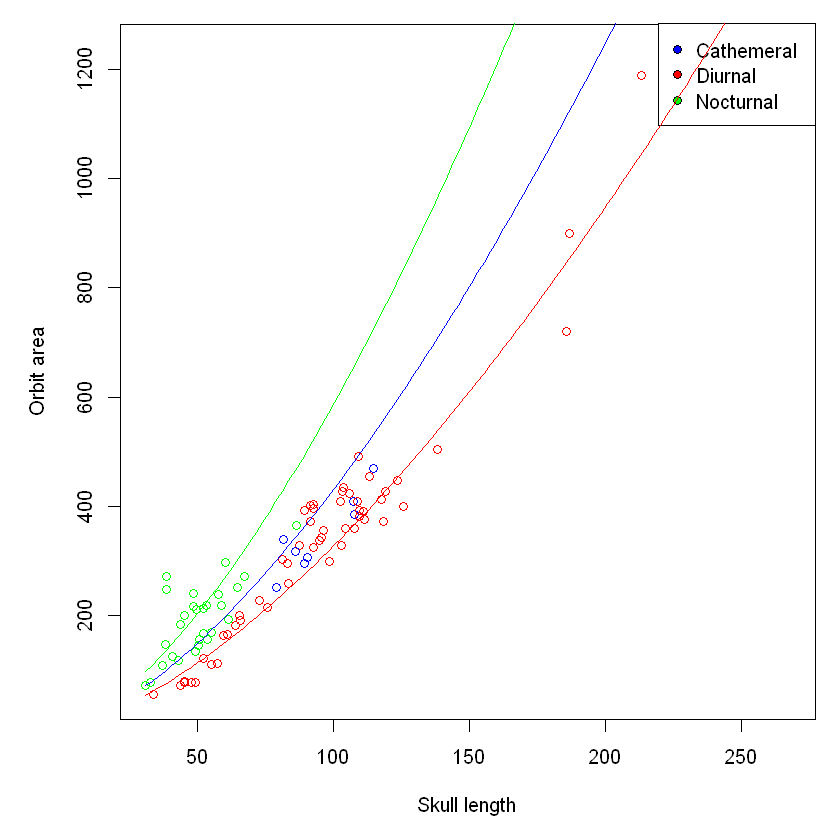

In [19]:
ptcolors <- setNames(c("blue", "red", "green"), nm = sort(unique(primate_eyes$Activity_pattern))) # colours for the three different activity patterns
dummy_skull_lengths <- seq(min(primate_eyes$Skull_length), max(primate_eyes$Skull_length), length.out = 100)

par(mar=c(5, 5, 1, 1))
plot(y = primate_eyes$Orbit_area, x = primate_eyes$Skull_length, pch = 21, col = ptcolors[primate_eyes$Activity_pattern], ylab = "Orbit area", xlab = "Skull length")
legend("topright", legend = names(ptcolors), pt.bg = ptcolors, pch = 21)
for (act in sort(unique(primate_eyes$Activity_pattern))) lines(x = dummy_skull_lengths, y = exp(predict(ancova, newdata = data.frame(Skull_length = dummy_skull_lengths,
                                                                                        Activity_pattern = rep(act, 100)))), col = ptcolors[act])    

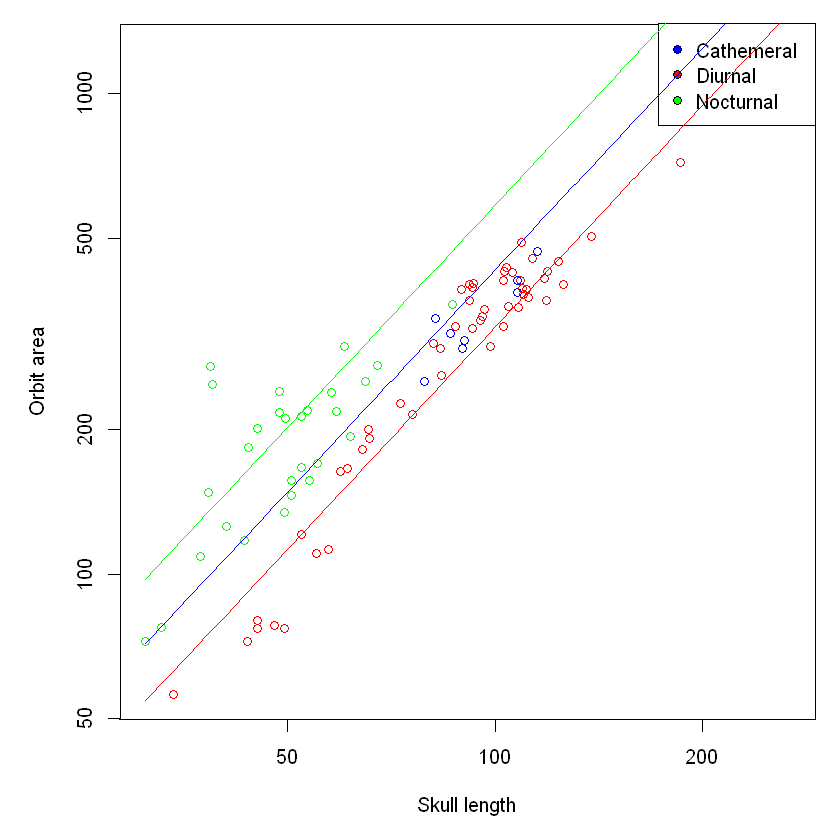

In [17]:
ptcolors <- setNames(c("blue", "red", "green"), nm = sort(unique(primate_eyes$Activity_pattern))) # colours for the three different activity patterns
dummy_skull_lengths <- seq(min(primate_eyes$Skull_length), max(primate_eyes$Skull_length), length.out = 100)

par(mar=c(5, 5, 1, 1))
plot(y = primate_eyes$Orbit_area, x = primate_eyes$Skull_length, pch = 21, col = ptcolors[primate_eyes$Activity_pattern], log = "xy", ylab = "Orbit area", xlab = "Skull length")
legend("topright", legend = names(ptcolors), pt.bg = ptcolors, pch = 21)
for (act in sort(unique(primate_eyes$Activity_pattern))) lines(x = dummy_skull_lengths, y = exp(predict(ancova, newdata = data.frame(Skull_length = dummy_skull_lengths,
                                                                                        Activity_pattern = rep(act, 100)))), col = ptcolors[act])    

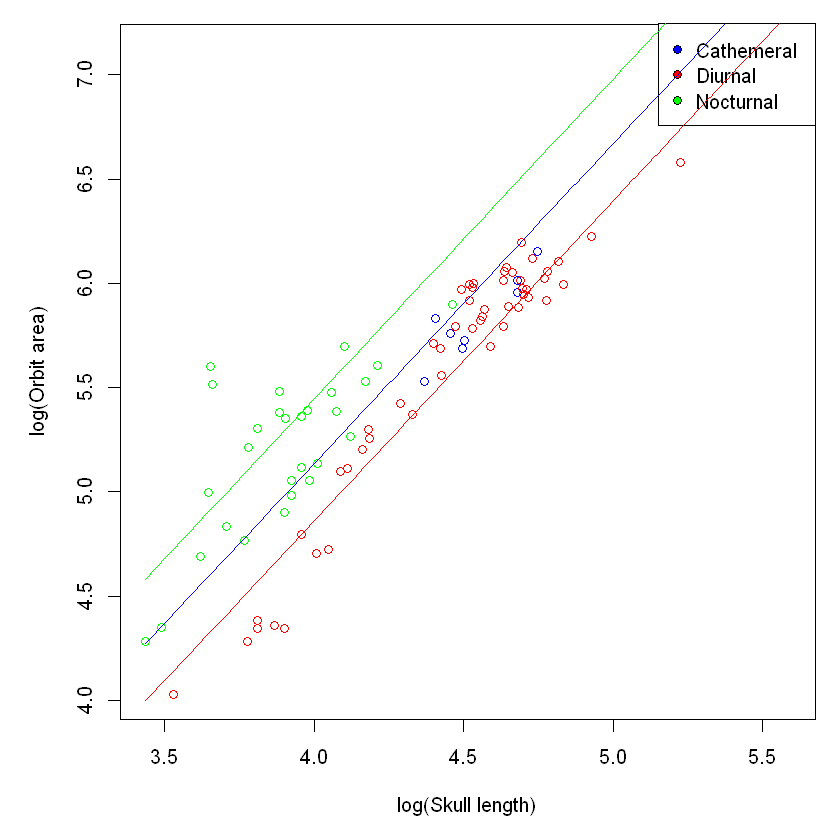

In [18]:
ptcolors <- setNames(c("blue", "red", "green"), nm = sort(unique(primate_eyes$Activity_pattern))) # colours for the three different activity patterns
dummy_skull_lengths <- seq(min(primate_eyes$Skull_length), max(primate_eyes$Skull_length), length.out = 100)

par(mar=c(5, 5, 1, 1))
plot(y = log(primate_eyes$Orbit_area), x = log(primate_eyes$Skull_length), pch = 21, col = ptcolors[primate_eyes$Activity_pattern], ylab = "log(Orbit area)", xlab = "log(Skull length)")
legend("topright", legend = names(ptcolors), pt.bg = ptcolors, pch = 21)
for (act in sort(unique(primate_eyes$Activity_pattern))) lines(x = log(dummy_skull_lengths), y = predict(ancova, newdata = data.frame(Skull_length = dummy_skull_lengths, Activity_pattern = rep(act, 100))),
                                                               col = ptcolors[act])    